# 사회복지시설·특수학교·장애인평생교육시설 × 이용목적콜 지역 패턴 분석

07_1~07_3(의료기관 × 의료목적콜)에서 쓴 분석 구조(구 단위 시설 수 vs 콜 건수 산점도 + Spearman rho, "탐색 목적, 인과관계 아님")를 그대로 계승해, 대상 기관을 **사회복지시설·특수학교·장애인평생교육시설**로 바꿔 3개 트랙으로 반복한다.

## 3개 트랙

| 트랙 | 기관 | 모집단 | 비교 대상 콜 |
|---|---|---|---|
| 1 | 사회복지시설 | 지오코딩 성공 + `시도_카카오`=="서울특별시" | 전체콜 / 의료목적콜 |
| 2 | 특수학교 | 32개 전부 서울 | 전체콜 / 의료목적콜 / 학교목적콜후보 |
| 3 | 장애인평생교육시설 | 29개 전부 서울 | 전체콜 / 의료목적콜 |

## §2 결정사항 (2026-09-11 확정)

사회복지시설·장애인평생교육시설은 `이용목적` 컬럼에 대응할 만한 카테고리가 없어(가장 유력한 후보 "기타"는 77.71%로 대리 지표로 쓰기엔 근거가 약함) **전체콜/의료목적콜만** 비교한다. 특수학교만 `통학/출근`+`예약통학/출근`(전체의 1.45%)을 **"학교목적콜후보"**로 묶어 세 번째 비교 대상으로 추가한다.

**면책 문구**: "학교목적콜후보"는 일반 직장 통근도 섞여 있을 수 있는 분석상 매핑이며, 실제 특수학교 통학 여부를 확인한 것이 아니다(07_3의 "장애유형→진료과목" 매핑과 동일한 성격의 한정).

계획 문서: `notebooks_docs_lye/260908_08_사회복지시설_특수학교_이용목적콜_분석_계획.md` (v5, 2026-09-11)


In [1]:
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

boarding_path = DATA_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
df.head()


C:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv


전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


In [2]:
use_cols = ["출발구", "출발동", "목적구", "목적동", "승차일시", "하차일시", "취소일시", "이용목적"]

missing_counts = df[use_cols].isna().sum()
print("사용 컬럼 결측치 개수")
display(missing_counts.to_frame("결측치_건수"))


사용 컬럼 결측치 개수


,결측치_건수
출발구,1
출발동,1
목적구,1
목적동,1
승차일시,245361
하차일시,245423
취소일시,1477193
이용목적,0


## 데이터 출처

**메인 데이터**: `data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv` — 02/04_1~04_3/07_x와 동일 소스.

**시설 데이터 3종** (2026-09-08 지오코딩 완료, `notebooks_docs_lye/260908_...계획.md` §3 참고):
- `사회복지시설_서울시_25개구_merged_행정동_파생컬럼추가.csv` (7,085건 중 지오코딩+서울 확인 기준 사용)
- `서울시_특수학교_기본정보_행정동_파생컬럼추가.csv` (32개, 100% 서울)
- `교육부_국립특수교육원_장애인평생교육기관현황_서울_processed_행정동_파생컬럼추가.csv` (29개, 100% 서울)

**의료목적 필터**: 07_1~07_3과 동일 정의 재사용 — `이용목적 ∈ {치료, 재활, 예약치료, 예약재활, 치료광역}`.


In [3]:
SEOUL_25 = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

completed = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
].copy()
print(f"탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)")

seoul_dest = completed[completed["목적구"].isin(SEOUL_25)].copy()
print(f"탑승완료 중 서울 25구 목적지: {len(seoul_dest):,} / {len(completed):,} ({len(seoul_dest) / len(completed) * 100:.1f}%)")


탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


탑승완료 중 서울 25구 목적지: 1,369,283 / 1,477,067 (92.7%)


In [4]:
MEDICAL_PURPOSES = {"치료", "재활", "예약치료", "예약재활", "치료광역"}  # 07_1~07_3과 동일 정의
SCHOOL_PURPOSES_CANDIDATE = {"통학/출근", "예약통학/출근"}  # 특수학교 "학교목적콜후보" — 일반 통근 포함 가능(면책, 셀 1 참고)

seoul_dest["의료목적"] = seoul_dest["이용목적"].isin(MEDICAL_PURPOSES)
seoul_dest["학교목적후보"] = seoul_dest["이용목적"].isin(SCHOOL_PURPOSES_CANDIDATE)

print(f"의료목적콜 비중: {seoul_dest['의료목적'].mean() * 100:.2f}%")
print(f"학교목적콜후보 비중: {seoul_dest['학교목적후보'].mean() * 100:.2f}%")

gu_calls = (
    seoul_dest.groupby("목적구")
    .agg(전체콜=("이용목적", "size"), 의료목적콜=("의료목적", "sum"), 학교목적콜후보=("학교목적후보", "sum"))
    .reindex(SEOUL_25)
    .reset_index()
    .rename(columns={"목적구": "자치구"})
)
display(gu_calls)


의료목적콜 비중: 9.25%
학교목적콜후보 비중: 1.28%


,자치구,전체콜,의료목적콜,학교목적콜후보
0,종로구,42322,5015,1515
1,중구,24064,1523,939
2,용산구,25766,1960,280
3,성동구,32287,3225,296
4,광진구,41518,3695,511
5,동대문구,53680,6664,852
6,중랑구,56697,4629,310
7,성북구,47196,3249,615
8,강북구,44792,3579,256
9,도봉구,47460,3164,369


In [5]:
def scatter_with_rho(ax, x, y, xlabel, ylabel, title, color="#4c78a8"):
    """07_1 스타일: 구 단위 산점도 + 추세선 + Spearman rho 주석 (07_1~07_3과 동일 패턴)"""
    ax.scatter(x, y, s=45, alpha=0.7, color=color)
    # 자치구 라벨은 호출부에서 annotate로 별도 처리(자치구명이 x,y와 별개 컬럼이라 이 함수는 값만 받음)

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, slope * x_line + intercept, linestyle="--", color="#e45756", alpha=0.7, linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    ax.text(
        0.05, 0.95, f"Spearman rho = {rho:.3f}\n(p={p:.3f})", transform=ax.transAxes,
        fontsize=9, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="#e45756"),
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    return rho, p


rho_records = []  # (트랙, 콜종류, rho, p) 누적 — Q4에서 사용


## 트랙 1 — 사회복지시설

**Q1**: 사회복지시설 수(개수)가 목적지 콜건수와 탐색적 관계를 보이는가?
**Q2**: 전체콜 대비 의료목적콜에서 관계의 강도·방향이 달라지는가?


In [6]:
welfare_raw = pd.read_csv(DATA_DIR / "사회복지시설_서울시_25개구_merged_행정동_파생컬럼추가.csv", encoding="utf-8-sig")
print(f"사회복지시설 지오코딩 시도 대상: {len(welfare_raw):,}건")

welfare_seoul = welfare_raw[welfare_raw["시도_카카오"] == "서울특별시"].copy()
print(f"서울로 확인된 사회복지시설: {len(welfare_seoul):,}건 ({len(welfare_seoul) / len(welfare_raw) * 100:.1f}%)")
print("(지오코딩 실패·타 시도 매칭 건은 이 필터로 자연히 제외됨 — 07_x의 '매칭 실패는 숨기지 않는다' 원칙과 동일)")

welfare_gu_count = (
    welfare_seoul.groupby("자치구_카카오").size().reindex(SEOUL_25, fill_value=0).reset_index()
)
welfare_gu_count.columns = ["자치구", "사회복지시설_수"]

welfare_track = gu_calls.merge(welfare_gu_count, on="자치구", how="left")
assert len(welfare_track) == 25, "25개 자치구가 모두 모이지 않음"
assert welfare_track["사회복지시설_수"].notna().all(), "사회복지시설_수 결측 발생 — 자치구명 매칭 확인 필요"
display(welfare_track)


사회복지시설 지오코딩 시도 대상: 7,085건
서울로 확인된 사회복지시설: 6,889건 (97.2%)
(지오코딩 실패·타 시도 매칭 건은 이 필터로 자연히 제외됨 — 07_x의 '매칭 실패는 숨기지 않는다' 원칙과 동일)


,자치구,전체콜,의료목적콜,학교목적콜후보,사회복지시설_수
0,종로구,42322,5015,1515,117
1,중구,24064,1523,939,103
2,용산구,25766,1960,280,127
3,성동구,32287,3225,296,168
4,광진구,41518,3695,511,222
5,동대문구,53680,6664,852,290
6,중랑구,56697,4629,310,335
7,성북구,47196,3249,615,305
8,강북구,44792,3579,256,293
9,도봉구,47460,3164,369,334


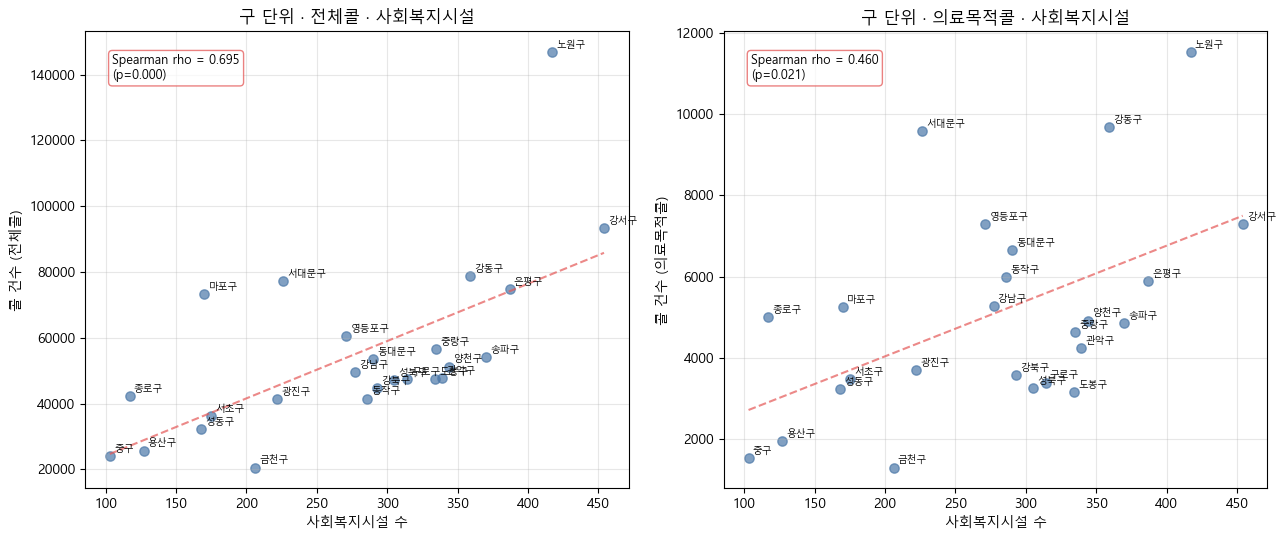

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, call_col in zip(axes, ["전체콜", "의료목적콜"]):
    rho, p = scatter_with_rho(
        ax, welfare_track["사회복지시설_수"], welfare_track[call_col],
        "사회복지시설 수", f"콜 건수 ({call_col})", f"구 단위 · {call_col} · 사회복지시설",
    )
    for _, row in welfare_track.iterrows():
        ax.annotate(row["자치구"], (row["사회복지시설_수"], row[call_col]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    rho_records.append(("사회복지시설", call_col, rho, p))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_08_welfare_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


In [8]:
# 사회복지시설 중 "장애인 관련 시설"만 별도 분류 (§3-3의 6개 상위유형 그룹, 계획 문서 기준 합계 722개)
DISABILITY_FACILITY_TYPES = {
    "장애인거주시설", "장애인지역사회재활시설", "장애인직업재활시설",
    "장애인의료재활시설", "장애인복지시설", "장애인생산품판매시설",
}

welfare_seoul["상위유형"] = welfare_seoul["시설종류명(시설유형)"].str.extract(r"\(([^)]+)\)")

disability_facility = welfare_seoul[welfare_seoul["상위유형"].isin(DISABILITY_FACILITY_TYPES)].copy()
print(f"장애인 관련 시설(6종 합계, 서울 확인 기준): {len(disability_facility):,}개")
display(disability_facility["상위유형"].value_counts())

disability_gu_count = (
    disability_facility.groupby("자치구_카카오").size().reindex(SEOUL_25, fill_value=0).reset_index()
)
disability_gu_count.columns = ["자치구", "장애인관련시설_수"]

disability_track = gu_calls.merge(disability_gu_count, on="자치구", how="left")
assert len(disability_track) == 25, "25개 자치구가 모두 모이지 않음"
display(disability_track[["자치구", "전체콜", "장애인관련시설_수"]])


장애인 관련 시설(6종 합계, 서울 확인 기준): 673개


상위유형
장애인지역사회재활시설    268
장애인거주시설        251
장애인직업재활시설      145
장애인의료재활시설        5
장애인복지시설          2
장애인생산품판매시설       2
Name: count, dtype: int64

,자치구,전체콜,장애인관련시설_수
0,종로구,42322,8
1,중구,24064,13
2,용산구,25766,10
3,성동구,32287,17
4,광진구,41518,16
5,동대문구,53680,12
6,중랑구,56697,13
7,성북구,47196,9
8,강북구,44792,31
9,도봉구,47460,28


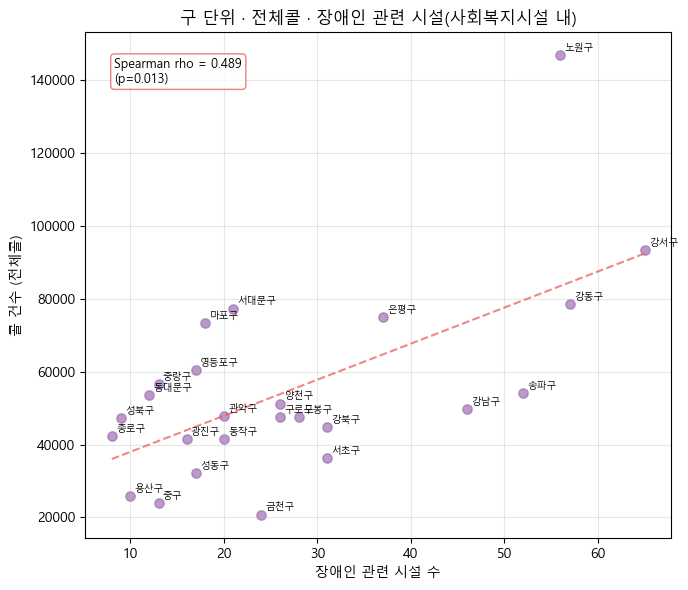

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

rho, p = scatter_with_rho(
    ax, disability_track["장애인관련시설_수"], disability_track["전체콜"],
    "장애인 관련 시설 수", "콜 건수 (전체콜)", "구 단위 · 전체콜 · 장애인 관련 시설(사회복지시설 내)",
    color="#9d6fb0",
)
for _, row in disability_track.iterrows():
    ax.annotate(
        row["자치구"], (row["장애인관련시설_수"], row["전체콜"]),
        fontsize=7, xytext=(3, 3), textcoords="offset points",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig5_08_disability_facility_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


**[관찰]** 장애인 관련 시설(6종 합계, 서울 확인 기준 673개)만 좁혀서 보면 전체콜과의 구 단위 상관은 **rho=0.489(p=0.013)**로, 사회복지시설 전체(7,085개 기준)의 rho=0.695보다 약해졌다 — 오히려 사회복지시설 전체 중 의료목적콜과의 상관(rho=0.460)과 비슷한 수준이다.

**[해석]** 사회복지시설 전체의 강한 상관(0.695)은 노인 관련 시설이 67.6%를 차지하는 구성(§3-3)이 주로 견인했을 가능성이 있다 — 장애인 관련 시설만 떼어내면 그 효과가 줄어들면서 상관이 약해진다. 다만 rho=0.489·p=0.013은 여전히 통계적으로 유의한 수준이라, "장애인 관련 시설이 많은 구에 콜택시 이용도 많다"는 관계 자체는 남아있다고 볼 수 있다.

**[추가 검증 필요]** 노원구·강서구처럼 장애인 관련 시설 수가 가장 많은 구(56개·65개)가 실제로 전체콜도 최상위권(146,831건·93,425건)인 반면, 강북구(31개)처럼 시설은 중간이지만 콜은 상대적으로 적은(44,792건) 구도 있어 — 이 관계가 몇몇 특이값(노원구·강서구)에 의해 견인되는지는 아래 §Q4 방식의 이상치 민감도 확인이 필요하다.


**[관찰]** 사회복지시설 수는 전체콜과 강한 양의 상관을 보였다(구 단위 Spearman rho=0.695, p<0.001, n=25). 의료목적콜로 좁히면 상관이 뚜렷하게 약해진다(rho=0.460, p=0.021) — 여전히 유의하지만 절반 가까이 감소했다.

**[해석]** 사회복지시설이 많은 구는 전반적인 콜택시 이용 자체가 많은 경향이 뚜렷하다(생활 인프라·고령 인구 밀집 지역과 겹칠 가능성). 다만 "의료목적"으로만 좁히면 관계가 약해지는 것으로 보아, 사회복지시설 밀집도가 의료 수요보다는 **전반적인 이동 수요**와 더 강하게 얽혀 있는 것으로 보인다 — 사회복지시설의 67.6%가 노인 관련 시설(§3-3)이라는 점과 맞물려, 고령층의 일상적 이동(전체콜)이 이 상관을 주로 견인했을 가능성이 있다.


## 트랙 2 — 특수학교

**Q1·Q2**: 위와 동일한 관점(전체콜/의료목적콜).
**Q3**: 학교목적콜후보에서는 관계가 더 뚜렷해지는가? (§2 면책 문구 적용)


In [10]:
school_raw = pd.read_csv(DATA_DIR / "서울시_특수학교_기본정보_행정동_파생컬럼추가.csv", encoding="utf-8-sig")
print(f"특수학교: {len(school_raw):,}개")

school_seoul = school_raw[school_raw["시도_카카오"] == "서울특별시"].copy()
print(f"서울로 확인된 특수학교: {len(school_seoul):,}개 ({len(school_seoul) / len(school_raw) * 100:.1f}%)")

school_gu_count = (
    school_seoul.groupby("자치구_카카오").size().reindex(SEOUL_25, fill_value=0).reset_index()
)
school_gu_count.columns = ["자치구", "특수학교_수"]

school_track = gu_calls.merge(school_gu_count, on="자치구", how="left")
assert len(school_track) == 25, "25개 자치구가 모두 모이지 않음"
display(school_track)


특수학교: 32개
서울로 확인된 특수학교: 32개 (100.0%)


,자치구,전체콜,의료목적콜,학교목적콜후보,특수학교_수
0,종로구,42322,5015,1515,4
1,중구,24064,1523,939,0
2,용산구,25766,1960,280,0
3,성동구,32287,3225,296,0
4,광진구,41518,3695,511,1
5,동대문구,53680,6664,852,0
6,중랑구,56697,4629,310,0
7,성북구,47196,3249,615,1
8,강북구,44792,3579,256,4
9,도봉구,47460,3164,369,1


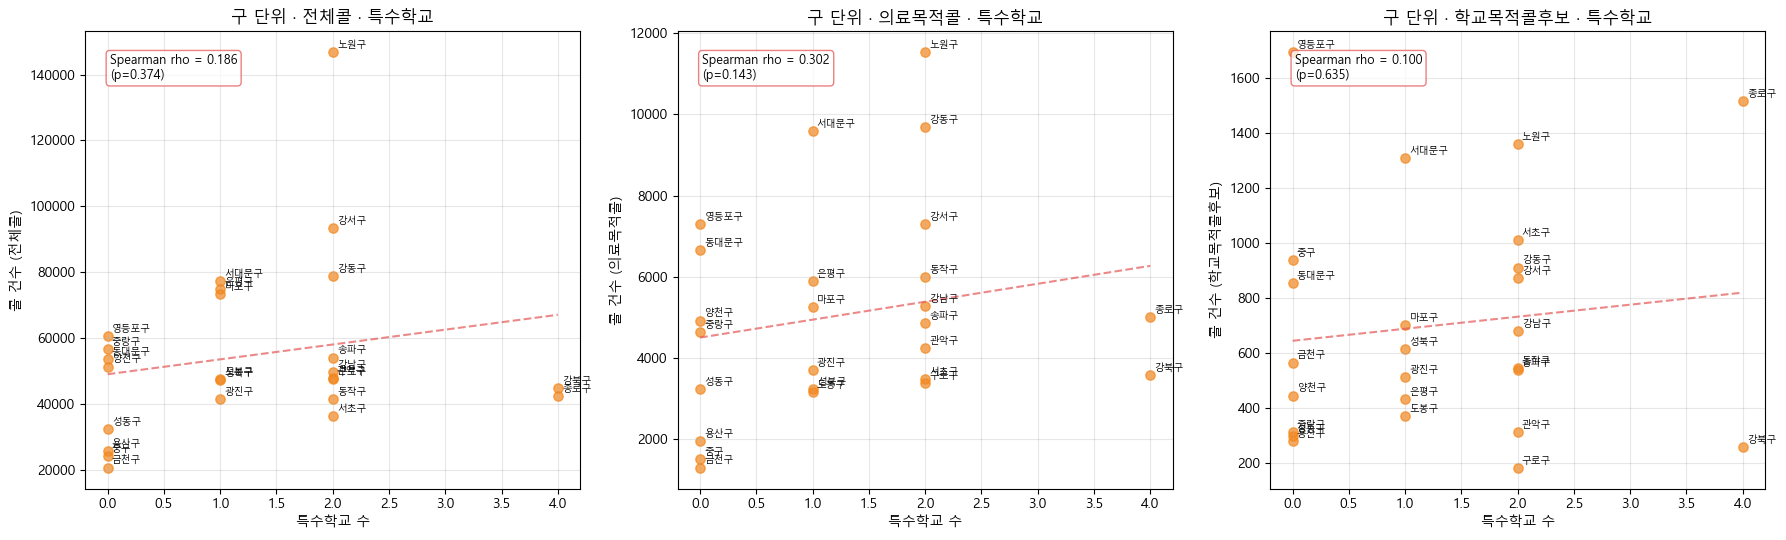

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, call_col in zip(axes, ["전체콜", "의료목적콜", "학교목적콜후보"]):
    rho, p = scatter_with_rho(
        ax, school_track["특수학교_수"], school_track[call_col],
        "특수학교 수", f"콜 건수 ({call_col})", f"구 단위 · {call_col} · 특수학교",
        color="#f58518",
    )
    for _, row in school_track.iterrows():
        ax.annotate(row["자치구"], (row["특수학교_수"], row[call_col]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    rho_records.append(("특수학교", call_col, rho, p))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_08_school_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


**[관찰]** 특수학교는 세 콜종류 어디에서도 통계적으로 유의한 상관을 보이지 않았다(전체콜 rho=0.186·p=0.374, 의료목적콜 rho=0.302·p=0.143, 학교목적콜후보 rho=0.100·p=0.635, n=25). Q3에서 기대했던 "학교목적콜후보에서 더 뚜렷해진다"는 예상과 달리, 오히려 세 지표 중 가장 약한 상관을 보였다.

**[해석]** 특수학교는 32개뿐이고 25개 구 중 상당수가 0~1개만 보유해(§3-1) 표본 자체가 통계적 관계를 검출하기엔 너무 작고 편향돼 있을 가능성이 크다. "학교목적콜후보"(통학/출근)가 일반 직장 통근과 섞여 있다는 면책 문구(셀 1)를 고려하면, 이 지표가 실제 특수학교 통학 수요를 제대로 대리하지 못했을 가능성도 있다. **유의하지 않다는 것은 "관계가 없다"를 증명한 것이 아니라 "이 표본·이 지표로는 관계를 찾지 못했다"는 뜻으로 해석해야 한다.**


## 트랙 3 — 장애인평생교육시설

**Q1·Q2**: 위와 동일한 관점(전체콜/의료목적콜).


In [12]:
edu_raw = pd.read_csv(
    DATA_DIR / "교육부_국립특수교육원_장애인평생교육기관현황_서울_processed_행정동_파생컬럼추가.csv", encoding="utf-8-sig"
)
print(f"장애인평생교육시설: {len(edu_raw):,}개")

edu_seoul = edu_raw[edu_raw["시도_카카오"] == "서울특별시"].copy()
print(f"서울로 확인된 장애인평생교육시설: {len(edu_seoul):,}개 ({len(edu_seoul) / len(edu_raw) * 100:.1f}%)")

edu_gu_count = (
    edu_seoul.groupby("자치구_카카오").size().reindex(SEOUL_25, fill_value=0).reset_index()
)
edu_gu_count.columns = ["자치구", "장애인평생교육시설_수"]

edu_track = gu_calls.merge(edu_gu_count, on="자치구", how="left")
assert len(edu_track) == 25, "25개 자치구가 모두 모이지 않음"
display(edu_track)


장애인평생교육시설: 29개
서울로 확인된 장애인평생교육시설: 29개 (100.0%)


,자치구,전체콜,의료목적콜,학교목적콜후보,장애인평생교육시설_수
0,종로구,42322,5015,1515,2
1,중구,24064,1523,939,0
2,용산구,25766,1960,280,1
3,성동구,32287,3225,296,2
4,광진구,41518,3695,511,1
5,동대문구,53680,6664,852,1
6,중랑구,56697,4629,310,1
7,성북구,47196,3249,615,2
8,강북구,44792,3579,256,1
9,도봉구,47460,3164,369,1


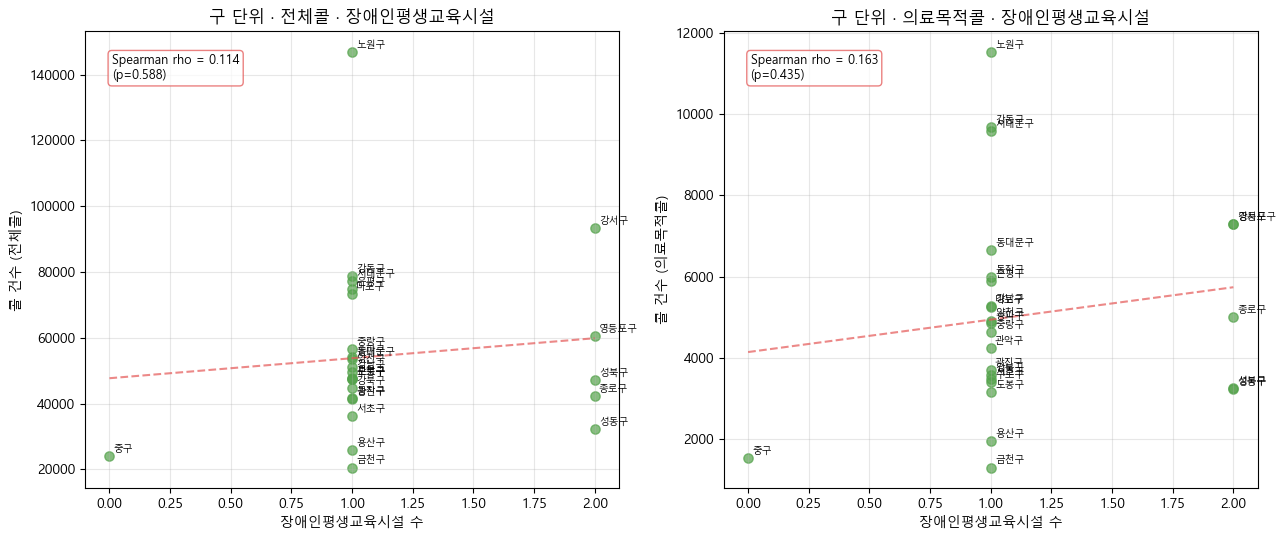

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, call_col in zip(axes, ["전체콜", "의료목적콜"]):
    rho, p = scatter_with_rho(
        ax, edu_track["장애인평생교육시설_수"], edu_track[call_col],
        "장애인평생교육시설 수", f"콜 건수 ({call_col})", f"구 단위 · {call_col} · 장애인평생교육시설",
        color="#54a24b",
    )
    for _, row in edu_track.iterrows():
        ax.annotate(row["자치구"], (row["장애인평생교육시설_수"], row[call_col]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    rho_records.append(("장애인평생교육시설", call_col, rho, p))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_08_edu_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


**[관찰]** 장애인평생교육시설도 특수학교와 마찬가지로 유의한 상관을 보이지 않았다(전체콜 rho=0.114·p=0.588, 의료목적콜 rho=0.163·p=0.435, n=25).

**[해석]** 29개 기관이 25개 구에 거의 1개씩 고르게 분포해(§3-1, 24개 구가 1개, 3개 구만 2개) 구 간 변동폭 자체가 작다 — 상관관계를 검출하기 어려운 구조다. 특수학교와 마찬가지로 표본 크기·분산 부족이 원인일 가능성이 크며, "관계 없음"으로 단정하지 않는다.


In [14]:
rho_df = pd.DataFrame(rho_records, columns=["트랙", "콜종류", "rho", "p"])
display(rho_df)


,트랙,콜종류,rho,p
0,사회복지시설,전체콜,0.695385,0.000114
1,사회복지시설,의료목적콜,0.460000,0.020686
2,특수학교,전체콜,0.185701,0.374145
3,특수학교,의료목적콜,0.301563,0.142927
4,특수학교,학교목적콜후보,0.099714,0.635337
5,장애인평생교육시설,전체콜,0.113699,0.588406
6,장애인평생교육시설,의료목적콜,0.163312,0.435382


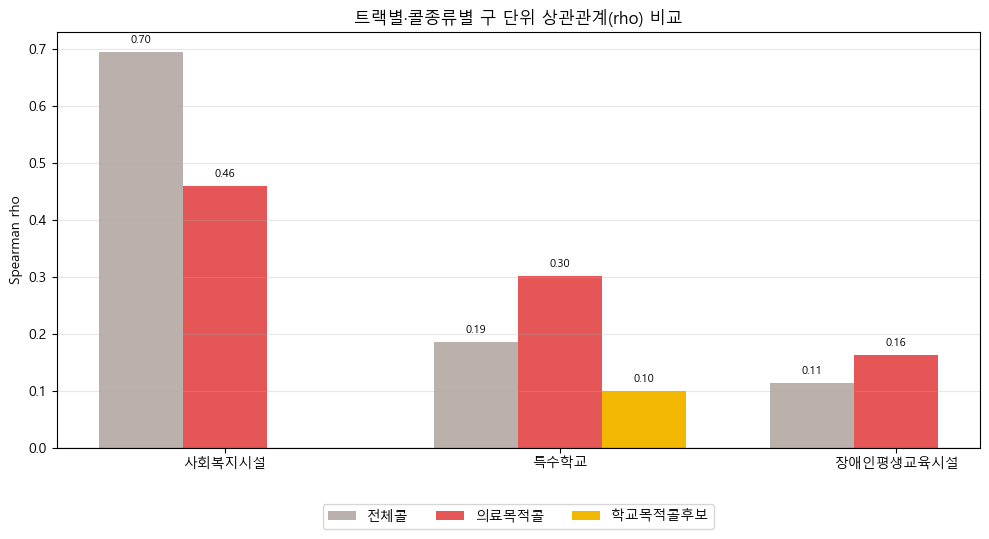

In [15]:
call_types = ["전체콜", "의료목적콜", "학교목적콜후보"]
tracks = ["사회복지시설", "특수학교", "장애인평생교육시설"]
colors = {"전체콜": "#bab0ac", "의료목적콜": "#e45756", "학교목적콜후보": "#f2b701"}

x = np.arange(len(tracks))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, call_col in enumerate(call_types):
    values = []
    for track in tracks:
        row = rho_df[(rho_df["트랙"] == track) & (rho_df["콜종류"] == call_col)]
        values.append(row["rho"].iloc[0] if len(row) else np.nan)
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=call_col, color=colors[call_col])
    for bar, v in zip(bars, values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * np.sign(v or 1),
                    f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tracks)
ax.set_ylabel("Spearman rho")
ax.set_title("트랙별·콜종류별 구 단위 상관관계(rho) 비교")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_08_rho_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Q4 해석 — 트랙 간 비교

**[관찰]** 세 트랙 중 **사회복지시설만 유의한 상관을 보였다**(전체콜·의료목적콜 모두 p<0.05). 특수학교·장애인평생교육시설은 모든 콜종류에서 유의하지 않았다(p>0.14). 상관 강도 순위는 사회복지시설(0.46~0.70) ≫ 특수학교(0.10~0.30) > 장애인평생교육시설(0.11~0.16) 순이다.

**[해석]** 07_1~07_3에서 의료기관(수백~수천 개 단위)으로 확인했던 "시설 수 vs 콜 건수" 관계는, 시설 절대 개수가 극히 적은(29~32개) 트랙에서는 표본 크기 문제로 재현되지 않았다. 이는 **가설 자체의 기각이라기보다 이번 3개 파일의 표본 규모 한계**로 해석해야 한다 — 07_x가 다룬 의료기관(14,856개)과 이번 시설(29~7,085개)은 개수 자릿수 자체가 다르다. 사회복지시설(7,085개, 07_x 규모에 근접)만 유일하게 유의한 결과가 나온 것이 이 해석을 뒷받침한다.


In [16]:
# Q5(경량): 사회복지시설 — 동 단위 vs 구 단위 rho가 같은 방향인지 가볍게 확인
# 주의: 목적동(콜)과 행정동(시설) 표기가 정규화되지 않아 일부 매칭 손실 가능 — 참고용 체크(07_2에서 지적된 동명 이슈와 동일 성격)
dong_calls = (
    seoul_dest.groupby("목적동")
    .agg(전체콜=("이용목적", "size"), 의료목적콜=("의료목적", "sum"))
    .reset_index()
    .rename(columns={"목적동": "행정동"})
)

welfare_dong_count = welfare_seoul.groupby("행정동").size().reset_index(name="사회복지시설_수")

welfare_dong_track = dong_calls.merge(welfare_dong_count, on="행정동", how="inner")
print(f"동 단위 매칭된 행정동 수: {len(welfare_dong_track):,}개 (콜 목적동 vs 시설 행정동 교집합, 표기 차이로 일부 손실 가능)")

for call_col in ["전체콜", "의료목적콜"]:
    rho_gu = rho_df[(rho_df["트랙"] == "사회복지시설") & (rho_df["콜종류"] == call_col)]["rho"].iloc[0]
    rho_dong, p_dong = stats.spearmanr(welfare_dong_track["사회복지시설_수"], welfare_dong_track[call_col])
    print(f"{call_col}: 구 단위 rho={rho_gu:.3f} vs 동 단위 rho={rho_dong:.3f} (p={p_dong:.3f}) — 방향 {'동일' if (rho_gu >= 0) == (rho_dong >= 0) else '반대'}")


동 단위 매칭된 행정동 수: 224개 (콜 목적동 vs 시설 행정동 교집합, 표기 차이로 일부 손실 가능)
전체콜: 구 단위 rho=0.695 vs 동 단위 rho=0.424 (p=0.000) — 방향 동일
의료목적콜: 구 단위 rho=0.460 vs 동 단위 rho=0.298 (p=0.000) — 방향 동일


In [17]:
save_path = DATA_DIR / "region_facility_purpose_correlation_summary_20251231.csv"
rho_df.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {save_path}")
display(rho_df)


저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_facility_purpose_correlation_summary_20251231.csv


,트랙,콜종류,rho,p
0,사회복지시설,전체콜,0.695385,0.000114
1,사회복지시설,의료목적콜,0.460000,0.020686
2,특수학교,전체콜,0.185701,0.374145
3,특수학교,의료목적콜,0.301563,0.142927
4,특수학교,학교목적콜후보,0.099714,0.635337
5,장애인평생교육시설,전체콜,0.113699,0.588406
6,장애인평생교육시설,의료목적콜,0.163312,0.435382


## 종합 인사이트

**[관찰]**
- 사회복지시설: 전체콜 rho=0.695(p<0.001), 의료목적콜 rho=0.460(p=0.021) — 유일하게 유의한 트랙
- 특수학교: 세 콜종류 모두 유의하지 않음(rho 0.10~0.30, p>0.14)
- 장애인평생교육시설: 두 콜종류 모두 유의하지 않음(rho 0.11~0.16, p>0.43)
- Q5(경량): 사회복지시설의 구 단위 상관(0.695/0.460)이 동 단위 상관(0.424/0.298)보다 강하지만 방향은 동일 — 매칭된 224개 행정동 기준(표기 정규화 없는 경량 체크)

**[해석]** 3개 트랙 중 사회복지시설만 07_1~07_3과 유사한 수준의 유의한 지역 패턴을 보였고, 나머지 두 트랙(특수학교·장애인평생교육시설)은 시설 개수 자체가 적어(29~32개) 25개 구 단위 분석으로는 통계적 관계를 검출하기 어려웠다. 사회복지시설도 의료목적콜로 좁히면 관계가 약해지는 것으로 보아, "사회복지시설 밀집 = 의료 수요"보다는 "사회복지시설 밀집 = 전반적 이동 수요(특히 고령층)"에 가까운 해석이 더 설득력 있다.

**[추가 검증 필요]**
- 사회복지시설 29종 상위유형별 세분화(노인시설 67.6% vs 장애인 관련 시설 10.2%, §3-3) — 장애인 관련 시설만 따로 떼면 결과가 달라질 수 있다.
- 특수학교·장애인평생교육시설은 표본이 적어 구 단위보다 더 세밀한 단위(동 단위 또는 개별 시설 인근 반경)로 재검토가 필요할 수 있다.
- "학교목적콜후보"(통학/출근)가 실제 특수학교 통학을 제대로 대리하는지는 확인되지 않았다 — 일반 통근과 분리할 수 있는 추가 정보가 없다면 이 지표의 신뢰도는 제한적이다.

**한계**: 사회복지시설 지오코딩 실패 73건·타 시도 매칭 196건(전체 2.8%)은 분석에서 자연히 제외됐다(임의 보정하지 않음, `260908_...계획.md` §3-6 원칙 계승). 이용목적→시설 매핑은 전부 분석상 매핑이며 실제 방문 목적을 확인한 것이 아니다.


## 부가 시각화 — 장애인 관련 시설 수 × 전체콜 순유입·순유출 지도

07_2에서 만든 지도(파스텔 다이버징 색상 + 흰색 경계선 + 그림자가 있는 원형 마커)를 그대로 재사용하되, 색상은 **전체콜 순유입·순유출**(이 노트북의 메인 트랙인 사회복지시설 상관분석이 전체콜 기준으로 유의했던 것과 맞춤), 원 크기는 **장애인 관련 시설 수**로 바꾼다.

08 노트북에는 아직 순유입·순유출 계산이 없으므로 아래 셀에서 02_od_flow_same_vs_diff_gu.ipynb와 동일한 방식(출발구·목적구 모두 서울 25구인 탑승완료 건 기준 유입-유출)으로 새로 계산한다.


In [18]:
# 전체콜 순유입·순유출 계산 (02_od_flow_same_vs_diff_gu.ipynb와 동일 방식)
seoul_od = completed[
    completed["출발구"].isin(SEOUL_25) & completed["목적구"].isin(SEOUL_25)
].copy()
print(f"탑승완료 중 서울 25구 내부 이동(출발·목적 모두 서울): {len(seoul_od):,} / {len(completed):,} ({len(seoul_od) / len(completed) * 100:.1f}%)")

out_by_gu = seoul_od.groupby("출발구").size()
in_by_gu = seoul_od.groupby("목적구").size()

net_flow_df = pd.DataFrame({
    "자치구": SEOUL_25,
    "유입건수": [in_by_gu.get(gu, 0) for gu in SEOUL_25],
    "유출건수": [out_by_gu.get(gu, 0) for gu in SEOUL_25],
})
net_flow_df["순유입건수"] = net_flow_df["유입건수"] - net_flow_df["유출건수"]

display(net_flow_df.sort_values("순유입건수", ascending=False).reset_index(drop=True))


탑승완료 중 서울 25구 내부 이동(출발·목적 모두 서울): 1,362,668 / 1,477,067 (92.3%)


,자치구,유입건수,유출건수,순유입건수
0,영등포구,60371,56802,3569
1,종로구,42262,39105,3157
2,중구,23987,20988,2999
3,은평구,74553,71896,2657
4,광진구,41447,39692,1755
5,강북구,44575,43828,747
6,동작구,41459,40912,547
7,성동구,32112,31570,542
8,강남구,49366,48834,532
9,용산구,25722,25328,394


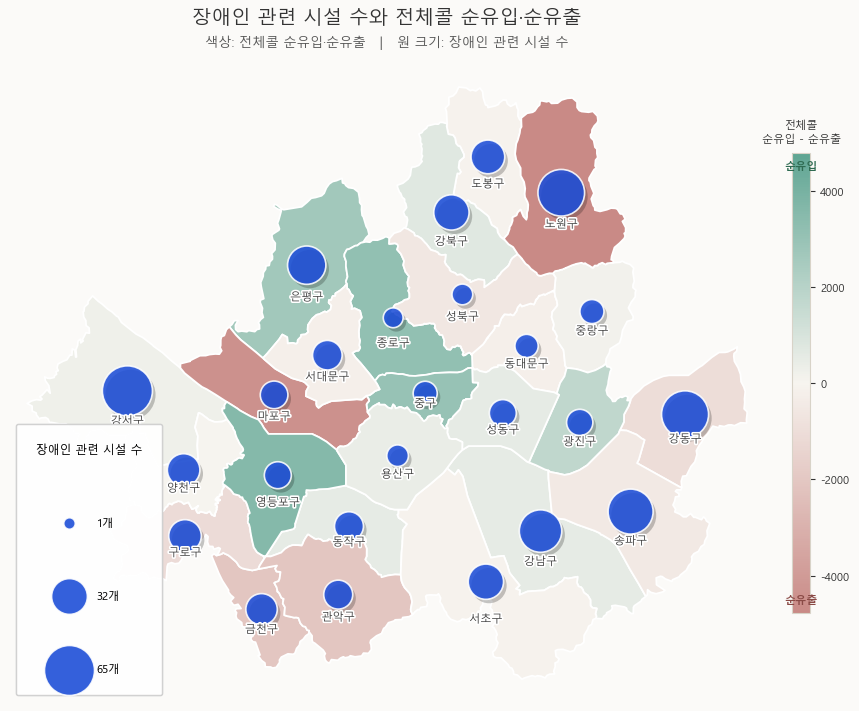

In [19]:
# 지도 시각화: 색상 = 전체콜 순유입·순유출, 원 크기 = 장애인 관련 시설 수
# (07_2_medical_destination_analysis_and_insights.ipynb의 지도 스타일을 그대로 재사용)
import json as _json
import math
import urllib.request

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.patheffects as pe

GEOJSON_URL = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/juso/2015/json/seoul_municipalities_geo_simple.json"
with urllib.request.urlopen(GEOJSON_URL) as resp:
    seoul_geojson = _json.loads(resp.read().decode("utf-8"))

net_flow_map = dict(zip(net_flow_df["자치구"], net_flow_df["순유입건수"]))
disability_map = dict(zip(disability_track["자치구"], disability_track["장애인관련시설_수"]))


def polygon_centroid(coords):
    """단순 다각형(exterior ring)의 면적 가중 중심점 — 02·07_2와 동일 로직"""
    area = cx = cy = 0.0
    for i in range(len(coords) - 1):
        x0, y0 = coords[i]
        x1, y1 = coords[i + 1]
        cross = x0 * y1 - x1 * y0
        area += cross
        cx += (x0 + x1) * cross
        cy += (y0 + y1) * cross
    area *= 0.5
    if area == 0:
        xs = [p[0] for p in coords]
        ys = [p[1] for p in coords]
        return sum(xs) / len(xs), sum(ys) / len(ys)
    return cx / (6 * area), cy / (6 * area)


patches, color_values, label_positions = [], [], []
bubble_x, bubble_y, bubble_count = [], [], []
all_lons, all_lats = [], []

for feature in seoul_geojson["features"]:
    gu_name = feature["properties"]["SIG_KOR_NM"]
    exterior = feature["geometry"]["coordinates"][0]
    patches.append(Polygon(exterior, closed=True))
    color_values.append(net_flow_map[gu_name])

    cx, cy = polygon_centroid(exterior)
    lat_span = max(pt[1] for pt in exterior) - min(pt[1] for pt in exterior)
    all_lons.extend(pt[0] for pt in exterior)
    all_lats.extend(pt[1] for pt in exterior)

    n_fac = disability_map[gu_name]
    if n_fac > 0:  # 장애인 관련 시설이 없는 구는 원을 표시하지 않는다
        bubble_x.append(cx)
        bubble_y.append(cy)
        bubble_count.append(n_fac)
        label_positions.append((gu_name, cx, cy - lat_span * 0.18))
    else:
        label_positions.append((gu_name, cx, cy))

# 색상: 파스텔 다이버징(02·07_2와 동일), 0 중심 좌우 대칭(절댓값 큰 쪽 기준)
max_abs = max(abs(v) for v in color_values)
norm = Normalize(vmin=-max_abs, vmax=max_abs)
diverging_cmap = LinearSegmentedColormap.from_list("net_flow_diverging", ["#c98a86", "#f7f4ef", "#5fa593"])

# 원 크기: 장애인 관련 시설 수에 비례, 최소~최대 폭을 넓게(07_2와 동일 기준)
MIN_SIZE, MAX_SIZE = 50, 1300
max_fac = max(bubble_count)
bubble_sizes = [MIN_SIZE + (n / max_fac) * (MAX_SIZE - MIN_SIZE) for n in bubble_count]

BUBBLE_COLOR = "#1d4ed8"
SHADOW_DX, SHADOW_DY = 0.0018, -0.0018

fig, ax = plt.subplots(figsize=(9.5, 9.5))

collection = PatchCollection(patches, cmap=diverging_cmap, norm=norm, edgecolor="#ffffff", linewidths=1.3)
collection.set_array(color_values)
ax.add_collection(collection)

ax.scatter(
    [x + SHADOW_DX for x in bubble_x], [y + SHADOW_DY for y in bubble_y], s=bubble_sizes,
    facecolor="#000000", alpha=0.22, edgecolor="none", zorder=3,
)
ax.scatter(
    bubble_x, bubble_y, s=bubble_sizes,
    facecolor=BUBBLE_COLOR, alpha=0.88, edgecolor="white", linewidths=1.2, zorder=4,
)

for gu_name, lx, ly in label_positions:
    ax.text(
        lx, ly, gu_name,
        ha="center", va="center", fontsize=8, color="#3a3a3a", zorder=5,
        path_effects=[pe.withStroke(linewidth=2.4, foreground="white")],
    )

ax.set_xlim(min(all_lons) - 0.01, max(all_lons) + 0.01)
ax.set_ylim(min(all_lats) - 0.01, max(all_lats) + 0.01)
ax.set_aspect(1 / math.cos(math.radians(sum(all_lats) / len(all_lats))))
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor("#fbfaf8")
fig.patch.set_facecolor("#fbfaf8")

ax.set_title("장애인 관련 시설 수와 전체콜 순유입·순유출", fontsize=14, pad=30, color="#333333")
ax.text(
    0.5, 1.025, "색상: 전체콜 순유입·순유출   |   원 크기: 장애인 관련 시설 수",
    transform=ax.transAxes, ha="center", va="bottom", fontsize=9.5, color="#555555",
)

cbar = fig.colorbar(collection, ax=ax, shrink=0.5, aspect=25, pad=0.03)
cbar.outline.set_edgecolor("#d8d3c8")
cbar.ax.set_title("전체콜\n순유입 - 순유출", fontsize=8, pad=8, color="#333333")
cbar.ax.tick_params(labelsize=8, colors="#333333")
cbar.ax.text(0.5, 0.985, "순유입", transform=cbar.ax.transAxes, ha="center", va="top",
             fontsize=8, color="#2f6b52", fontweight="bold")
cbar.ax.text(0.5, 0.015, "순유출", transform=cbar.ax.transAxes, ha="center", va="bottom",
             fontsize=8, color="#8a4a46", fontweight="bold")

legend_values = sorted({v for v in [1, max(1, round(max_fac / 2)), max_fac] if 0 < v <= max_fac})
legend_handles = [
    ax.scatter(
        [], [], s=MIN_SIZE + (v / max_fac) * (MAX_SIZE - MIN_SIZE),
        facecolor=BUBBLE_COLOR, alpha=0.88, edgecolor="white", linewidths=1.2, label=f"{v}개",
    )
    for v in legend_values
]
size_legend = ax.legend(
    handles=legend_handles, title="장애인 관련 시설 수", loc="lower left",
    frameon=True, fontsize=8, title_fontsize=8.5, labelspacing=5.5, borderpad=1.8, handletextpad=1.5,
)
ax.add_artist(size_legend)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig6_08_disability_facility_netflow_map.png", dpi=120, bbox_inches="tight")
plt.show()


**[관찰]** 장애인 관련 시설이 가장 많은 구(강서구 65개·강동구 57개·노원구 56개·송파구 52개·강남구 46개)는 대부분 전체콜 **순유출**(노원구 -4,782·강동구 -1,040·송파구 -522) 또는 순유입·순유출이 거의 0에 가까운 구(강서구 +238·강남구 +532)다. 반대로 전체콜 순유입 최상위 구(영등포구 +3,569·종로구 +3,157·중구 +2,999·은평구 +2,657)는 장애인 관련 시설 수가 상대적으로 적다(17개·8개·13개·37개).

**[해석]** 장애인 관련 시설은 도심 접근성이 좋은 순유입 지역보다 오히려 외곽의 순유출 지역(노원구·강동구 등)에 더 많이 분포하는 경향이 보인다. 위 §Q1 산점도에서 확인한 "시설 수 많음 = 전체콜 많음"(rho=0.489) 관계와 함께 보면, 이 지역들의 콜 수요 자체는 크지만 그 수요가 순유입(다른 구에서 들어오는 형태)이 아니라 **그 구 안에서 발생해 다른 구로 나가는(순유출) 형태**로 나타난다는 뜻이다 — 즉 장애인 관련 시설이 많은 지역 주민들이 해당 시설을 이용한 뒤에도 다른 구(아마도 의료·상업 인프라가 더 밀집한 도심권)로 계속 이동한다는 해석이 가능하다.

**[추가 검증 필요]** 이 지도는 전체콜 기준이라 장애인 관련 시설 자체를 오가는 통행만 반영한 것은 아니다 — 07_2의 의료목적콜 순유입·순유출 지도와 겹쳐 보면 "장애인 관련 시설 밀집 지역이 의료목적으로도 순유출인지"까지 확인할 수 있다.
